In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from scipy import stats
import matplotlib.patches as mpatches
# ==========================================
# 1. 環境設定與路徑初始化
# ==========================================
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 
plt.rcParams['axes.unicode_minus'] = False 

# 設定路徑 (假設腳本在 notebooks/ 下)
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed"
FIGURE_PATH = PROJECT_ROOT / "outputs" / "figures"
TABLE_PATH = PROJECT_ROOT / "outputs" / "tables"

FIGURE_PATH.mkdir(parents=True, exist_ok=True)
TABLE_PATH.mkdir(parents=True, exist_ok=True)

# 讀取「全域刪除」後的乾淨資料 (現在兩者內容一致，讀任一即可)
df = pd.read_csv(DATA_PATH / "yrbs_prop_analysis.csv")
n_obs = len(df)


--- 正在執行行為變數分析 (n=12902) ---


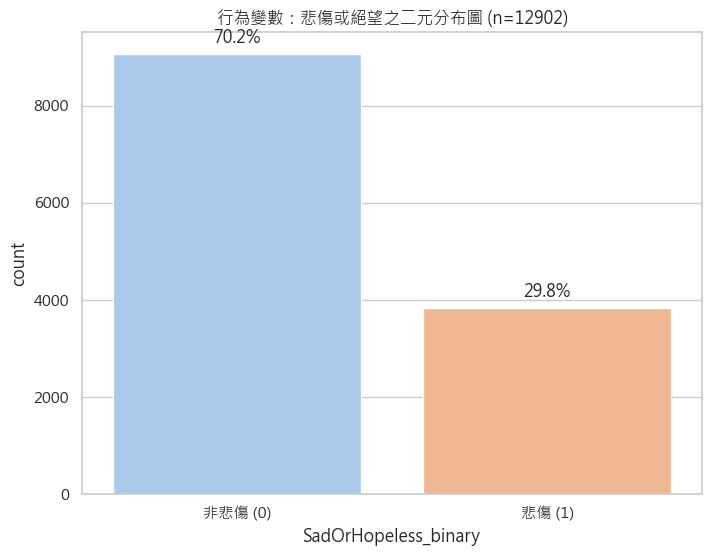

In [8]:
# ==========================================
# 2. 行為變數分析 (SadOrHopeless)
# ==========================================
print(f"\n--- 正在執行行為變數分析 (n={n_obs}) ---")

# (A) 次數分配表
binary_counts = df['SadOrHopeless_binary'].value_counts().sort_index()
binary_percent = df['SadOrHopeless_binary'].value_counts(normalize=True) * 100
binary_table = pd.DataFrame({'計數': binary_counts, '比例(%)': binary_percent})
binary_table.index = ['失敗 (0: 非悲傷)', '成功 (1: 悲傷)']
binary_table.to_csv(TABLE_PATH / "sad_binary_summary.csv", encoding='utf_8_sig')

# (B) 繪製長條圖
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='SadOrHopeless_binary', data=df, hue='SadOrHopeless_binary', palette='pastel', legend=False)
for p in ax.patches:
    ax.annotate(f'{100*p.get_height()/n_obs:.1f}%', (p.get_x()+p.get_width()/2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')
plt.title(f'行為變數：悲傷或絕望之二元分布圖 (n={n_obs})')
plt.xticks([0, 1], ['非悲傷 (0)', '悲傷 (1)'])
plt.savefig(FIGURE_PATH / "sad_bar_chart.png")
plt.show()


--- 正在執行連續變數分析 (n=12902) ---


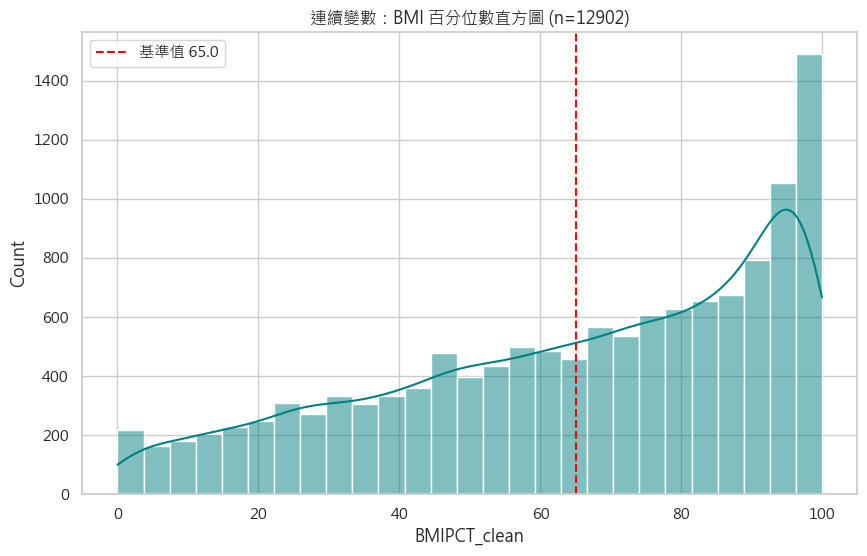

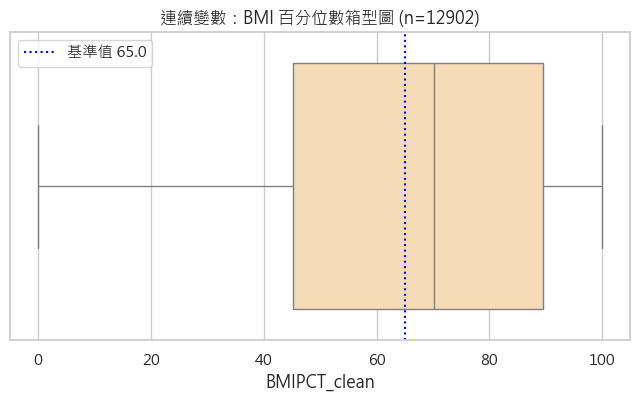


分析完成！所有圖表與表格已存檔。
有效樣本數一致性確認：12902


In [3]:
# ==========================================
# 3. 連續變數分析 (BMIPCT)
# ==========================================
print(f"\n--- 正在執行連續變數分析 (n={n_obs}) ---")

# (A) 描述性統計
bmi_stats = df['BMIPCT_clean'].describe()
bmi_summary = pd.DataFrame(bmi_stats)
bmi_summary.to_csv(TABLE_PATH / "bmi_stats_summary.csv", encoding='utf_8_sig')

# (B) IQR 離群值檢查
Q1 = bmi_stats['25%']
Q3 = bmi_stats['75%']
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['BMIPCT_clean'] < lower_bound) | (df['BMIPCT_clean'] > upper_bound)]

# (C) 繪製直方圖
plt.figure(figsize=(10, 6))
sns.histplot(df['BMIPCT_clean'], kde=True, color='teal')
plt.axvline(65.0, color='red', linestyle='--', label='基準值 65.0')
plt.title(f'連續變數：BMI 百分位數直方圖 (n={n_obs})')
plt.legend()
plt.savefig(FIGURE_PATH / "bmi_histogram.png")
plt.show()

# (D) 繪製箱型圖
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['BMIPCT_clean'], color='navajowhite', fliersize=5)
plt.axvline(65.0, color='blue', linestyle=':', label='基準值 65.0')
plt.title(f'連續變數：BMI 百分位數箱型圖 (n={n_obs})')
plt.legend()
plt.savefig(FIGURE_PATH / "bmi_boxplot.png")
plt.show()

print("\n分析完成！所有圖表與表格已存檔。")
print(f"有效樣本數一致性確認：{n_obs}")

In [7]:
# ==========================================
# 1. 環境設定與資料讀取
# ==========================================
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed"
TABLE_PATH = PROJECT_ROOT / "outputs" / "tables"

# 讀取全域刪除後的有效樣本 (n 會完全一致)
df = pd.read_csv(DATA_PATH / "yrbs_prop_analysis.csv")

# ==========================================
# 2. 單一樣本比例 Z 檢定 (SadOrHopeless)
# ==========================================
# 設定參數
count = df['SadOrHopeless_binary'].sum()  # 成功的次數 (悲傷)
nobs = len(df)                            # 總樣本數
p_null = 0.30                             # 基準值

# 執行檢定
z_stat, p_value_z = proportions_ztest(count, nobs, value=p_null, alternative='two-sided')

# 建構 95% 信賴區間
ci_low_z, ci_high_z = proportion_confint(count, nobs, alpha=0.05, method='normal')

# 整理結果
prop_test_res = pd.DataFrame({
    '項目': ['樣本有效人數 (n)', '悲傷人數', '樣本比例 (p_hat)', '檢定基準值 (p0)', 'Z 統計量', 'P 值', '95% CI 下界', '95% CI 上界'],
    '數值': [nobs, count, count/nobs, p_null, z_stat, p_value_z, ci_low_z, ci_high_z]
})
prop_test_res.to_csv(TABLE_PATH / "proportion_test_results.csv", index=False, encoding='utf_8_sig')
# ==========================================
# 3. 單一樣本 t 檢定 (BMIPCT)
# ==========================================
# 設定參數
bmi_data = df['BMIPCT_clean']
mu_0 = 65.0                               # 基準值

# 計算樣本統計量
x_bar = bmi_data.mean()
s = bmi_data.std()
n = len(bmi_data)

# 執行單一樣本 t 檢定
t_stat, p_val_t = stats.ttest_1samp(bmi_data, popmean=mu_0)

# 建構 95% 信賴區間 (使用 t 分布)
ci_t = stats.t.interval(confidence=0.95, df=n-1, loc=x_bar, scale=stats.sem(bmi_data))

# 整理結果
mean_test_res = pd.DataFrame({
    '項目': ['樣本有效人數 (n)', '樣本平均數', '標準差', '檢定基準值 (mu0)', 't 統計量', 'P 值', '95% CI 下界', '95% CI 上界'],
    '數值': [n, x_bar, s, mu_0, t_stat, p_val_t, ci_t[0], ci_t[1]]
})
mean_test_res.to_csv(TABLE_PATH / "mean_test_results.csv", index=False, encoding='utf_8_sig')

# ==========================================
# 4. 輸出摘要報告
# ==========================================
print("="*60)
print(f"推論統計摘要報告 (有效樣本 n = {nobs})")
print("="*60)
print(f"[比例 Z 檢定] P 值: {p_value_z:.4e}")
print(f"[平均數 t 檢定] P 值: {p_val_t:.4e}")
print("-"*60)
print("結果已成功儲存至 proportion_test_results.csv")
print("結果已成功儲存至 mean_test_results.csv")

推論統計摘要報告 (有效樣本 n = 12902)
[比例 Z 檢定] P 值: 5.8189e-01
[平均數 t 檢定] P 值: 4.7889e-01
------------------------------------------------------------
結果已成功儲存至 proportion_test_results.csv
結果已成功儲存至 mean_test_results.csv


--- 性別與悲傷比例交叉表 ---
            非悲傷 (0)    悲傷 (1)
Sex_Label                    
Female     0.627008  0.372992
Male       0.776545  0.223455


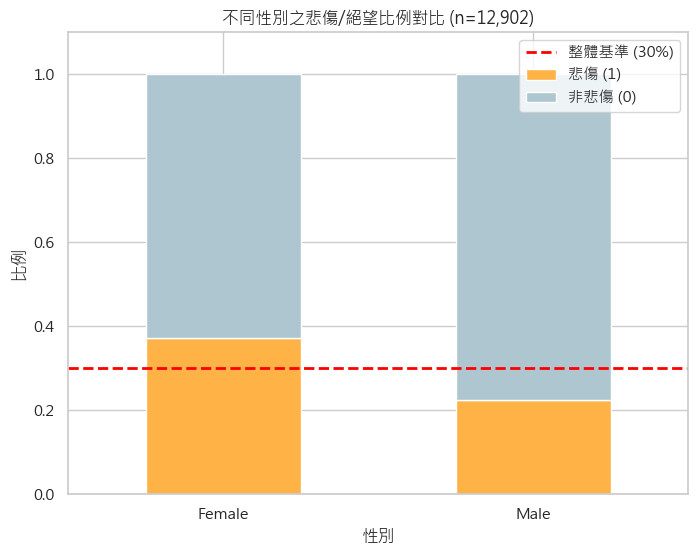


--- 雙樣本比例 Z 檢定結果 ---
       群組    悲傷人數  樣本總數      悲傷比例      Z 統計量  P 值
0  Female  2392.0  6413  0.372992  18.571831  0.0
1    Male  1450.0  6489  0.223455                

結論：P 值 (5.4318e-77) < 0.05，男女生在悲傷比例上有顯著差異。


In [15]:
# ==========================================
# 1. 環境設定與路徑初始化
# ==========================================
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 
plt.rcParams['axes.unicode_minus'] = False 

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed"
FIGURE_PATH = PROJECT_ROOT / "outputs" / "figures"
TABLE_PATH = PROJECT_ROOT / "outputs" / "tables"

# 讀取已包含性別的乾淨資料
df = pd.read_csv(DATA_PATH / "yrbs_prop_analysis.csv")

# ==========================================
# 2. 變數標籤化與交叉分析
# ==========================================
# 將性別代碼轉換為易讀標籤
df['Sex_Label'] = df['WhatIsYourSex'].map({1: 'Female', 2: 'Male'})

# (A) 建立次數表 (Count Table)
ct_counts = pd.crosstab(df['Sex_Label'], df['SadOrHopeless_binary'])
ct_counts.columns = ['非悲傷 (0)', '悲傷 (1)']
ct_counts.to_csv(TABLE_PATH / "sex_sad_count_table.csv", encoding='utf_8_sig')

# (B) 建立歸一化比例表 (Percentage Table)
ct_pct = pd.crosstab(df['Sex_Label'], df['SadOrHopeless_binary'], normalize='index')
ct_pct.columns = ['非悲傷 (0)', '悲傷 (1)']
print("--- 性別與悲傷比例交叉表 ---")
print(ct_pct)

# ==========================================
# 3. 進階視覺化：堆疊長條圖
# ==========================================
plt.figure(figsize=(8, 6))
# 重新排序確保 '悲傷 (1)' 在下方/上方方便對比
ct_pct_plot = ct_pct[['悲傷 (1)', '非悲傷 (0)']]
ax = ct_pct_plot.plot(kind='bar', stacked=True, color=['#ffb347', '#aec6cf'], ax=plt.gca())

# 加入整體基準線 (30%)
line = plt.axhline(0.3, color='red', linestyle='--', linewidth=2, label='整體基準 (30%)')

plt.title('不同性別之悲傷/絕望比例對比 (n=12,902)')
plt.ylabel('比例')
plt.xlabel('性別')
plt.legend(loc='upper right')
plt.xticks(rotation=0)
plt.ylim(0, 1.1)

plt.savefig(FIGURE_PATH / "sex_with_sad_bar_chart.png", dpi=300)
plt.show()

# ==========================================
# 4. 雙樣本比例 Z 檢定 (Two-sample Z-test)
# ==========================================
# 準備檢定數據
female_data = df[df['Sex_Label'] == 'Female']['SadOrHopeless_binary']
male_data = df[df['Sex_Label'] == 'Male']['SadOrHopeless_binary']

successes = [female_data.sum(), male_data.sum()]
nobs = [len(female_data), len(male_data)]

# 執行檢定
z_stat_sex, p_val_sex = proportions_ztest(count=successes, nobs=nobs)

# 儲存檢定結果
sex_z_test_res = pd.DataFrame({
    '群組': ['Female', 'Male'],
    '悲傷人數': [successes[0], successes[1]],
    '樣本總數': [nobs[0], nobs[1]],
    '悲傷比例': [successes[0]/nobs[0], successes[1]/nobs[1]],
    'Z 統計量': [z_stat_sex, ""],
    'P 值': [p_val_sex, ""]
})
sex_z_test_res.to_csv(TABLE_PATH / "sex_sad_proportion_z_test.csv", index=False, encoding='utf_8_sig')

print("\n--- 雙樣本比例 Z 檢定結果 ---")
print(sex_z_test_res)

if p_val_sex < 0.05:
    print(f"\n結論：P 值 ({p_val_sex:.4e}) < 0.05，男女生在悲傷比例上有顯著差異。")
else:
    print(f"\n結論：P 值 ({p_val_sex:.4e}) >= 0.05，男女生在悲傷比例上無顯著差異。")

--- BMI 分組統計摘要 ---
             count       mean        std           min        25%        50%  \
Sad_Status                                                                     
悲傷          3842.0  65.798882  27.357873  3.720000e-09  46.423696  71.288352   
非悲傷         9060.0  64.416979  27.568365  1.930000e-07  44.477392  69.776789   

                  75%        max  
Sad_Status                        
悲傷          90.226574  99.915189  
非悲傷         89.083347  99.939213  


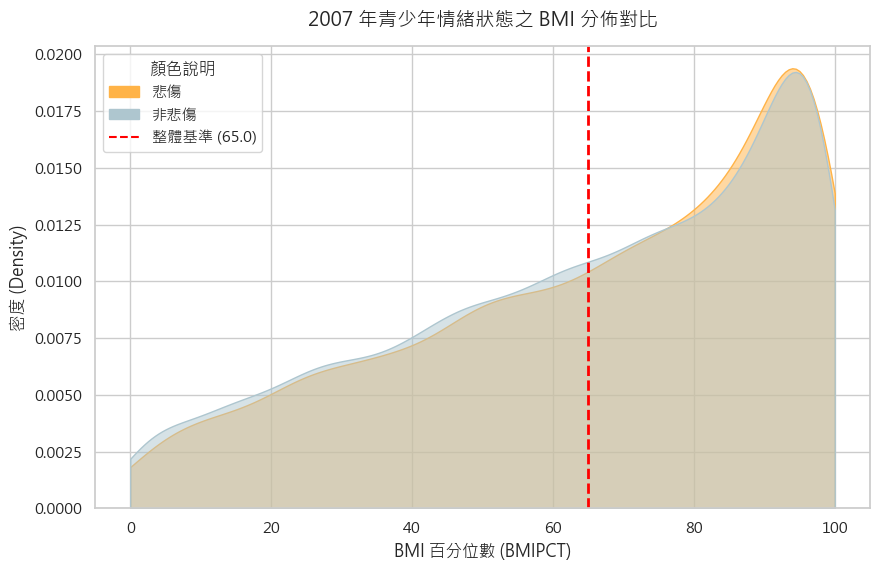


--- 獨立樣本 t 檢定結果 ---
          項目         數值
0      悲傷組平均  65.798882
1     非悲傷組平均  64.416979
2      平均值差異   1.381903
3      t 統計量   2.617659
4  P 值 (十進位)   0.008900

結論：P 值 (0.0089) < 0.05，悲傷與非悲傷組在 BMI 上有顯著差異。


In [23]:
# ==========================================
# 1. 環境設定與路徑初始化
# ==========================================
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 
plt.rcParams['axes.unicode_minus'] = False 

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed"
FIGURE_PATH = PROJECT_ROOT / "outputs" / "figures"
TABLE_PATH = PROJECT_ROOT / "outputs" / "tables"

# 讀取資料
df = pd.read_csv(DATA_PATH / "yrbs_prop_analysis.csv")
df['Sad_Status'] = df['SadOrHopeless_binary'].map({1: '悲傷', 0: '非悲傷'})

# ==========================================
# 2. 分組描述統計 (Summary Stats by Group)
# ==========================================
bmi_sad_summary = df.groupby('Sad_Status')['BMIPCT_clean'].describe()
bmi_sad_summary.to_csv(TABLE_PATH / "bmi_stats_by_sadness.csv", encoding='utf_8_sig')

print("--- BMI 分組統計摘要 ---")
print(bmi_sad_summary)

# ==========================================
# 3. KDE 密度分布圖
# ==========================================
plt.figure(figsize=(10, 6))

# 1. 定義顏色映射
# 根據你的喜好：藍色/藍綠色 = 非悲傷，橘色 = 悲傷
custom_palette = {'非悲傷': '#aec6cf', '悲傷': '#ffb347'}

# 2. 繪製 KDE
ax = sns.kdeplot(
    data=df, 
    x='BMIPCT_clean', 
    hue='Sad_Status', 
    fill=True, 
    palette=custom_palette, 
    clip=(0, 100), 
    alpha=0.5,
    common_norm=False,
    legend=False # 先關閉自動產生的圖例，我們手動做更準確的
)

# 3. 繪製紅色基準虛線
plt.axvline(65.0, color='red', linestyle='--', linewidth=2, label='整體基準 (65.0)')

# 4. 手動建立圖例物件 (確保顏色與標籤絕對對應)
# 建立代表「非悲傷」的藍色方塊
blue_patch = mpatches.Patch(color='#aec6cf', label='非悲傷')
# 建立代表「悲傷」的橘色方塊
orange_patch = mpatches.Patch(color='#ffb347', label='悲傷')
# 取得紅線的控制權
red_line = plt.Line2D([0], [0], color='red', linestyle='--', label='整體基準 (65.0)')

# 5. 將這些物件全部放入圖例中
plt.legend(handles=[orange_patch, blue_patch, red_line], title='顏色說明', loc='upper left')

# 6. 圖表裝飾
plt.title('2007 年青少年情緒狀態之 BMI 分佈對比', fontsize=14, pad=15)
plt.xlabel('BMI 百分位數 (BMIPCT)', fontsize=12)
plt.ylabel('密度 (Density)', fontsize=12)

plt.savefig(FIGURE_PATH / "bmi_kde_final_legend.png", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 4. 獨立樣本 t 檢定 (Independent t-test)
# ==========================================
# 準備兩組數據
bmi_sad = df[df['SadOrHopeless_binary'] == 1]['BMIPCT_clean']
bmi_not_sad = df[df['SadOrHopeless_binary'] == 0]['BMIPCT_clean']

# 執行 t 檢定 (假設變異數不相等，使用 Welch's t-test)
t_stat, p_val = stats.ttest_ind(bmi_sad, bmi_not_sad, equal_var=False)

# 整理結果
t_test_results = pd.DataFrame({
    '項目': ['悲傷組平均', '非悲傷組平均', '平均值差異', 't 統計量', 'P 值 (十進位)'],
    '數值': [bmi_sad.mean(), bmi_not_sad.mean(), bmi_sad.mean() - bmi_not_sad.mean(), t_stat, round(p_val, 4)]
})

t_test_results.to_csv(TABLE_PATH / "bmi_sad_diff_t_test.csv", index=False, encoding='utf_8_sig')

print("\n--- 獨立樣本 t 檢定結果 ---")
print(t_test_results)

if p_val < 0.05:
    print(f"\n結論：P 值 ({p_val:.4f}) < 0.05，悲傷與非悲傷組在 BMI 上有顯著差異。")
else:
    print(f"\n結論：P 值 ({p_val:.4f}) >= 0.05，兩組在 BMI 上沒有顯著差異。")